# 🧪 Bloque 4 — Sesión 1: Test chi-cuadrado y t-test de Student

**Módulo:** Depuración, Limpieza y Clasificación de Datos (5109)  
**Unidad Didáctica:** UD2 — Verificación estadística de la calidad de los datos  
**Duración estimada:** ~4 horas

---

### Contenidos de esta sesión
- **4.1** Test chi-cuadrado (χ²): independencia entre dos variables categóricas
- **4.2** T-test de Student: comparación de medias entre dos grupos y alternativa Mann-Whitney

### Criterios de evaluación asociados
> **(CE a)** Se han descrito las técnicas estadísticas de análisis de la calidad técnica de los datos.  
> **(CE b)** Se han aplicado técnicas de evaluación basadas en cálculos estadísticos para detectar la cobertura y el sesgo.  
> **(CE c)** Se ha documentado la descripción del resultado de las verificaciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, shapiro, levene

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

titanic = sns.load_dataset('titanic')
diamonds = sns.load_dataset('diamonds')
penguins = sns.load_dataset('penguins').dropna()

print('✅ Librerías y datasets cargados')

✅ Librerías y datasets cargados


---
## 4.1 Test chi-cuadrado (χ²) de independencia

### ¿Qué pregunta responde?

¿Existe asociación estadísticamente significativa entre dos variables categóricas, o su distribución conjunta es compatible con la independencia?

- **H₀:** las dos variables son independientes
- **H₁:** las dos variables NO son independientes

### Condiciones
- Variable 1 y Variable 2: categóricas
- Frecuencia esperada ≥ 5 en cada celda

> 💡 El test χ² dice si la asociación es significativa (sí/no), mientras que Cramér's V mide su fuerza (cuánto). Son complementarios.

In [2]:
# Test chi-cuadrado: sexo vs supervivencia (Titanic)
tabla = pd.crosstab(titanic['sex'], titanic['survived'])
print('Tabla de contingencia observada:')
print(tabla)
print()

chi2, p, dof, esperadas = chi2_contingency(tabla)

print(f'Estadístico χ²: {chi2:.4f}')
print(f'Grados de libertad: {dof}')
print(f'P-valor: {p:.6f}')
print()
print('Frecuencias ESPERADAS bajo independencia:')
print(pd.DataFrame(esperadas, index=tabla.index, columns=tabla.columns).round(1))
print()
if p < 0.05:
    print('✅ Rechazamos H₀: sexo y supervivencia NO son independientes (p < 0.05)')
else:
    print('❌ No rechazamos H₀: no hay evidencia suficiente de asociación')

Tabla de contingencia observada:
survived    0    1
sex               
female     81  233
male      468  109

Estadístico χ²: 260.7170
Grados de libertad: 1
P-valor: 0.000000

Frecuencias ESPERADAS bajo independencia:
survived      0      1
sex                   
female    193.5  120.5
male      355.5  221.5

✅ Rechazamos H₀: sexo y supervivencia NO son independientes (p < 0.05)


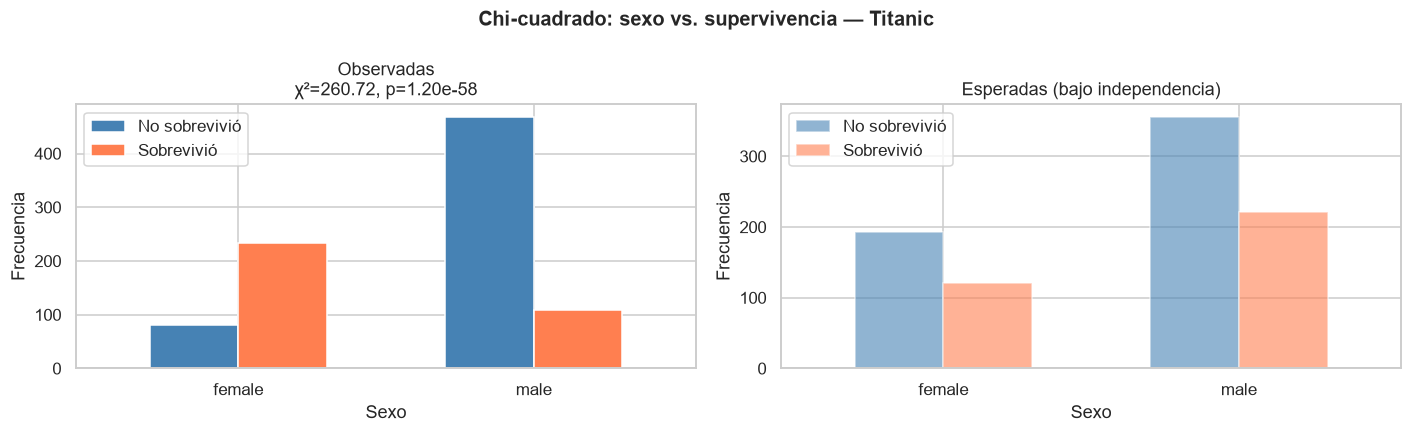

In [3]:
chi2, p, dof, esperadas = chi2_contingency(tabla)
tabla_esp = pd.DataFrame(esperadas, index=tabla.index, columns=tabla.columns)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tabla.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'],
           edgecolor='white', width=0.6)
axes[0].set_title(f'Observadas\nχ²={chi2:.2f}, p={p:.2e}')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['No sobrevivió', 'Sobrevivió'])

tabla_esp.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'],
               edgecolor='white', width=0.6, alpha=0.6)
axes[1].set_title('Esperadas (bajo independencia)')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No sobrevivió', 'Sobrevivió'])

plt.suptitle('Chi-cuadrado: sexo vs. supervivencia — Titanic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Residuos estandarizados

$$r_{ij} = \frac{O_{ij} - E_{ij}}{\sqrt{E_{ij}}}$$

Un valor |r| > 2 indica que esa celda contribuye significativamente al χ².

χ² = 102.889  |  gl = 2  |  p = 4.5493e-23
Rechazamos H₀ (α=0.05)

Residuos estandarizados (|r| > 2 → celda relevante):
survived     0     1
pclass              
1        -4.60  5.83
2        -1.54  1.95
3         3.99 -5.06



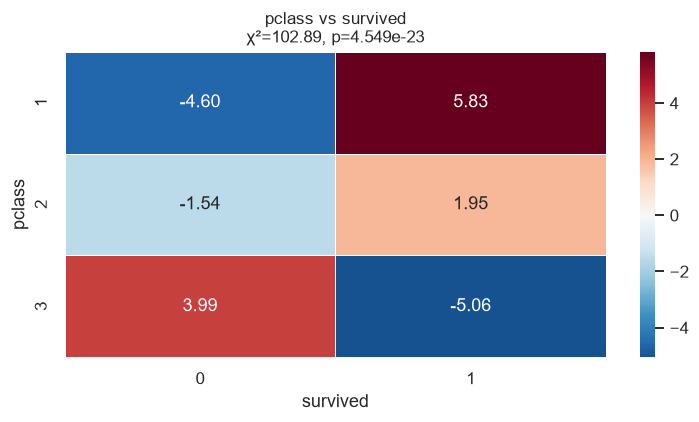

(np.float64(102.88898875696056), np.float64(4.549251711298793e-23), 2)

In [4]:
def chi2_con_residuos(col1, col2, df):
    """Ejecuta chi-cuadrado y muestra residuos estandarizados."""
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, esp = chi2_contingency(tabla)
    residuos = (tabla.values - esp) / np.sqrt(esp)
    df_res = pd.DataFrame(residuos, index=tabla.index, columns=tabla.columns)

    print(f'χ² = {chi2:.3f}  |  gl = {dof}  |  p = {p:.4e}')
    print(f'{"Rechazamos H₀" if p < 0.05 else "No rechazamos H₀"} (α=0.05)')
    print()
    print('Residuos estandarizados (|r| > 2 → celda relevante):')
    print(df_res.round(2))
    print()

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(df_res, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_title(f'{col1} vs {col2}\nχ²={chi2:.2f}, p={p:.3e}', fontsize=11)
    plt.tight_layout()
    plt.show()

    return chi2, p, dof

chi2_con_residuos('pclass', 'survived', titanic)

In [5]:
def chi2_multivariable(df, cols_cat, col_objetivo, alpha=0.05):
    """Aplica chi-cuadrado entre cada variable categórica y la variable objetivo."""
    from math import sqrt
    resultados = []
    for col in cols_cat:
        tmp = df[[col, col_objetivo]].dropna()
        tabla = pd.crosstab(tmp[col], tmp[col_objetivo])
        chi2, p, dof, esp = chi2_contingency(tabla)
        n = tabla.sum().sum()
        V = sqrt(chi2 / (n * (min(tabla.shape) - 1)))
        resultados.append({
            'Variable': col,
            'χ²': round(chi2, 3),
            'gl': dof,
            'p-valor': round(p, 6),
            "Cramér's V": round(V, 4),
            'Significativa': '✅' if p < alpha else '❌'
        })
    return pd.DataFrame(resultados).set_index('Variable').sort_values('p-valor')

cols_cat = ['sex', 'pclass', 'embarked', 'who', 'alone']
print("Relación de variables categóricas con 'survived':")
chi2_multivariable(titanic, cols_cat, 'survived')

Relación de variables categóricas con 'survived':


,χ²,gl,p-valor,Cramér's V,Significativa
Variable,,,,,
sex,260.717,1,0.000000,0.5409,✅
pclass,102.889,2,0.000000,0.3398,✅
who,283.923,2,0.000000,0.5645,✅
alone,36.001,1,0.000000,0.2010,✅
embarked,26.489,2,0.000002,0.1726,✅


---
## 4.2 T-test de Student

### ¿Qué pregunta responde?

Compara las **medias de dos grupos independientes**:

- **H₀:** μ₁ = μ₂
- **H₁:** μ₁ ≠ μ₂

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

### Condiciones
1. Muestras independientes
2. Variable dependiente numérica continua
3. Distribución aproximadamente normal en cada grupo (o n > 30)
4. Varianzas similares (la versión Welch relaja esta condición)

> 📌 `ttest_ind` usa por defecto Welch (`equal_var=False`), que es más robusta.

In [6]:
# T-test: ¿difiere la tarifa entre supervivientes y no supervivientes?
grupo_si = titanic.loc[titanic['survived'] == 1, 'fare'].dropna()
grupo_no = titanic.loc[titanic['survived'] == 0, 'fare'].dropna()

print(f'Supervivientes    — n={len(grupo_si):3d}  media={grupo_si.mean():.2f}  std={grupo_si.std():.2f}')
print(f'No supervivientes — n={len(grupo_no):3d}  media={grupo_no.mean():.2f}  std={grupo_no.std():.2f}')
print()

W1, p_norm1 = shapiro(grupo_si[:500])
W2, p_norm2 = shapiro(grupo_no[:500])
print(f'Normalidad Sí:  W={W1:.4f}, p={p_norm1:.4f} → {"✅" if p_norm1 > 0.05 else "⚠️ no normal"}')
print(f'Normalidad No:  W={W2:.4f}, p={p_norm2:.4f} → {"✅" if p_norm2 > 0.05 else "⚠️ no normal"}')
print()

t, p = ttest_ind(grupo_si, grupo_no, equal_var=False)
print(f'T-test de Welch: t={t:.4f}, p={p:.6f}')
if p < 0.05:
    print('✅ Rechazamos H₀: la tarifa media difiere significativamente entre grupos')
else:
    print('❌ No rechazamos H₀')

Supervivientes    — n=342  media=48.40  std=66.60
No supervivientes — n=549  media=22.12  std=31.39

Normalidad Sí:  W=0.5967, p=0.0000 → ⚠️ no normal
Normalidad No:  W=0.5110, p=0.0000 → ⚠️ no normal

T-test de Welch: t=6.8391, p=0.000000
✅ Rechazamos H₀: la tarifa media difiere significativamente entre grupos


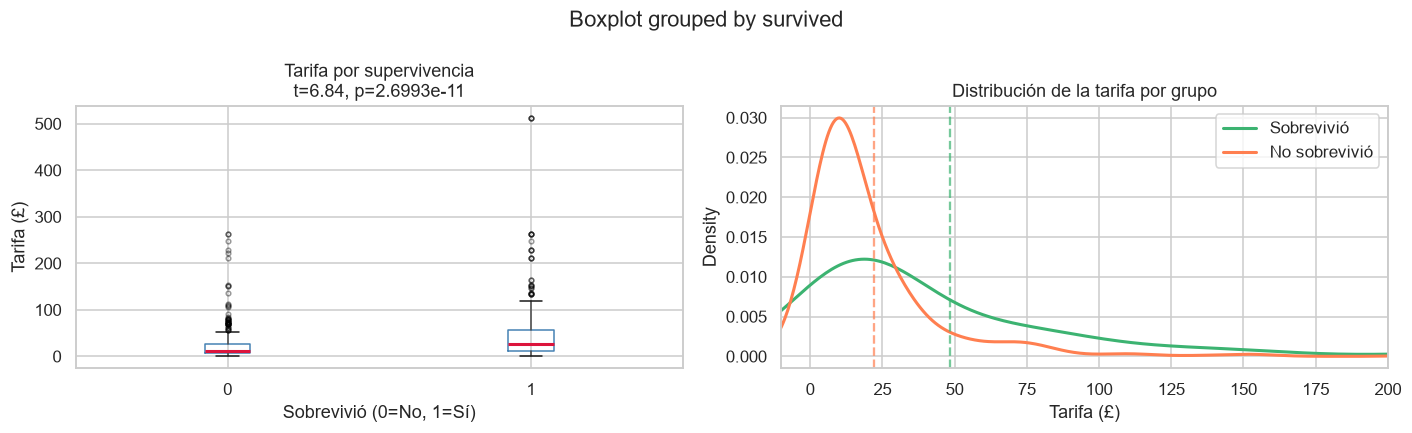

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

titanic.boxplot(column='fare', by='survived', ax=axes[0],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[0].set_xlabel('Sobrevivió (0=No, 1=Sí)')
axes[0].set_ylabel('Tarifa (£)')
axes[0].set_title(f'Tarifa por supervivencia\nt={t:.2f}, p={p:.4e}')
plt.sca(axes[0])
plt.title(f'Tarifa por supervivencia\nt={t:.2f}, p={p:.4e}')

grupo_si.plot.kde(ax=axes[1], color='mediumseagreen', linewidth=2, label='Sobrevivió')
grupo_no.plot.kde(ax=axes[1], color='coral', linewidth=2, label='No sobrevivió')
axes[1].axvline(grupo_si.mean(), color='mediumseagreen', linestyle='--', alpha=0.7)
axes[1].axvline(grupo_no.mean(), color='coral', linestyle='--', alpha=0.7)
axes[1].set_xlim(-10, 200)
axes[1].set_title('Distribución de la tarifa por grupo')
axes[1].set_xlabel('Tarifa (£)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Test de Levene para homocedasticidad
stat_lev, p_lev = levene(grupo_si, grupo_no)
print(f'Test de Levene: estadístico={stat_lev:.4f}, p={p_lev:.6f}')
print(f'{"⚠️ Varianzas distintas → usar Welch" if p_lev < 0.05 else "✅ Varianzas homogéneas"}')
print()
print(f"Varianza 'Sí':  {grupo_si.var():.2f}")
print(f"Varianza 'No':  {grupo_no.var():.2f}")

Test de Levene: estadístico=45.0996, p=0.000000
⚠️ Varianzas distintas → usar Welch

Varianza 'Sí':  4435.16
Varianza 'No':  985.22


### Alternativa no paramétrica: test de Mann-Whitney U

Cuando los grupos **no siguen una distribución normal**, el t-test puede dar resultados engañosos. La alternativa es el **test de Mann-Whitney U**, que trabaja con rangos.

- H₀: las distribuciones de los dos grupos son iguales
- No asume normalidad
- Más robusto ante outliers y asimetría

In [9]:
U, p_mw = mannwhitneyu(grupo_si, grupo_no, alternative='two-sided')
n1, n2 = len(grupo_si), len(grupo_no)
r_efecto = U / (n1 * n2)

print('Comparación t-test vs Mann-Whitney:')
print(f'  T-test (Welch):   t={t:.4f},  p={p:.6f}')
print(f'  Mann-Whitney U:   U={U:.1f},  p={p_mw:.6f}')
print()
print(f'Tamaño del efecto Mann-Whitney (r = U/(n1·n2)): {r_efecto:.4f}')
print('  r > 0.5 → grupo Sí tiende a pagar más')
print()
print('→ Ambos tests coinciden. Mann-Whitney es preferible porque fare no es normal.')

Comparación t-test vs Mann-Whitney:
  T-test (Welch):   t=6.8391,  p=0.000000
  Mann-Whitney U:   U=129951.5,  p=0.000000

Tamaño del efecto Mann-Whitney (r = U/(n1·n2)): 0.6921
  r > 0.5 → grupo Sí tiende a pagar más

→ Ambos tests coinciden. Mann-Whitney es preferible porque fare no es normal.


In [10]:
def comparar_dos_grupos(df, col_num, col_grupo, alpha=0.05):
    """Compara una variable numérica entre dos grupos con diagnóstico automático."""
    grupos = df[[col_num, col_grupo]].dropna()
    categorias = sorted(grupos[col_grupo].unique())
    if len(categorias) != 2:
        print(f'⚠️ Se esperan 2 grupos, se encontraron {len(categorias)}')
        return

    g1 = grupos.loc[grupos[col_grupo] == categorias[0], col_num]
    g2 = grupos.loc[grupos[col_grupo] == categorias[1], col_num]

    print('=' * 60)
    print(f"COMPARACIÓN: '{col_num}' por '{col_grupo}'")
    print('=' * 60)
    print(f"  Grupo '{categorias[0]}': n={len(g1)}, media={g1.mean():.3f}, std={g1.std():.3f}")
    print(f"  Grupo '{categorias[1]}': n={len(g2)}, media={g2.mean():.3f}, std={g2.std():.3f}")
    print()

    _, p_n1 = shapiro(g1[:500] if len(g1) > 500 else g1)
    _, p_n2 = shapiro(g2[:500] if len(g2) > 500 else g2)
    normal = p_n1 > alpha and p_n2 > alpha
    print(f'  Normalidad: p1={p_n1:.4f}, p2={p_n2:.4f} → {"✅ OK" if normal else "⚠️ No normal"}')

    _, p_lev = levene(g1, g2)
    homo = p_lev > alpha
    print(f'  Levene: p={p_lev:.4f} → {"✅ Homocedástico" if homo else "⚠️ Heterocedástico"}')
    print()

    if normal:
        t_val, p_val = ttest_ind(g1, g2, equal_var=homo)
        test_usado = f'T-test {"estándar" if homo else "de Welch"}'
        stat_str = f't={t_val:.4f}'
    else:
        U_val, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
        test_usado = 'Mann-Whitney U'
        stat_str = f'U={U_val:.1f}'

    print(f'  Test: {test_usado}  →  {stat_str}, p={p_val:.6f}')
    conclusion = '✅ Diferencia significativa' if p_val < alpha else '❌ Sin diferencia significativa'
    print(f'  Conclusión: {conclusion} (α={alpha})')
    print('=' * 60)
    print()

comparar_dos_grupos(titanic, 'age', 'survived')
comparar_dos_grupos(penguins, 'body_mass_g', 'sex')

COMPARACIÓN: 'age' por 'survived'
  Grupo '0': n=424, media=30.626, std=14.172
  Grupo '1': n=290, media=28.344, std=14.951

  Normalidad: p1=0.0000, p2=0.0014 → ⚠️ No normal
  Levene: p=0.2746 → ✅ Homocedástico

  Test: Mann-Whitney U  →  U=65278.0, p=0.160493
  Conclusión: ❌ Sin diferencia significativa (α=0.05)

COMPARACIÓN: 'body_mass_g' por 'sex'
  Grupo 'Female': n=165, media=3862.273, std=666.172
  Grupo 'Male': n=168, media=4545.685, std=787.629

  Normalidad: p1=0.0000, p2=0.0000 → ⚠️ No normal
  Levene: p=0.0143 → ⚠️ Heterocedástico

  Test: Mann-Whitney U  →  U=6874.5, p=0.000000
  Conclusión: ✅ Diferencia significativa (α=0.05)



---
## 🔧 Ejercicios

### Ejercicio 1 — Chi-cuadrado en Diamonds

Usa `chi2_multivariable()` para analizar qué variables están más asociadas con `cut`. ¿Qué dice el Cramér's V sobre la fuerza de esas asociaciones?

In [11]:
# chi2_multivariable(diamonds, ['color', 'clarity'], 'cut')

# Para el par más significativo:
# chi2_con_residuos('color', 'clarity', diamonds)

### Ejercicio 2 — T-test en Penguins

Usa `comparar_dos_grupos()` para analizar si `bill_length_mm` difiere entre machos y hembras. Repite filtrando solo la especie `Adelie`. ¿Cambia la conclusión?

In [12]:
# comparar_dos_grupos(penguins, 'bill_length_mm', 'sex')

# adelie = penguins[penguins['species'] == 'Adelie']
# comparar_dos_grupos(adelie, 'bill_length_mm', 'sex')

### Ejercicio 3 — Elegir el test correcto

Para cada escenario, indica qué test usarías y por qué:
1. ¿Difiere la proporción de corte `Ideal` entre colores `D` y `J`?
2. ¿Es diferente el precio entre `cut='Fair'` y `cut='Ideal'`? (revisa el sesgo)
3. ¿Existe asociación entre `color` y `clarity`?

In [13]:
# Escenario 1: proporciones → chi-cuadrado
# tmp = diamonds[diamonds['color'].isin(['D', 'J'])].copy()
# tmp['ideal'] = (tmp['cut'] == 'Ideal').astype(int)
# chi2_con_residuos('color', 'ideal', tmp)

# Escenario 2: precio → revisar normalidad y elegir t-test o Mann-Whitney
# comparar_dos_grupos(diamonds[diamonds['cut'].isin(['Fair', 'Ideal'])], 'price', 'cut')

# Escenario 3: asociación categórica
# chi2_con_residuos('color', 'clarity', diamonds)

---
## 📝 Resumen de la sesión

| Concepto | Clave |
|----------|-------|
| **Chi-cuadrado** | Independencia entre dos categóricas. p < 0.05 → asociación significativa. |
| **Residuos estand.** | Qué celdas contribuyen más a la diferencia. |r| > 2 → relevante. |
| **T-test de Welch** | Compara medias de 2 grupos. Robusto a varianzas distintas. Asume normalidad. |
| **Levene** | Verifica homocedasticidad. p < 0.05 → usar Welch. |
| **Mann-Whitney U** | Alternativa no paramétrica. Usa rangos. No asume normalidad. |
| **Flujo decisión** | Normalidad OK → t-test. No normal o n pequeño → Mann-Whitney. |

### 🔜 Próxima sesión
**Bloque 4 — Sesión 2:** ANOVA, Kruskal-Wallis, Mutual Information y documentación para el modelado.